In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
import SEDfromSFH as sed
import synphot
from synphot import units

#### Calculating observed spectra from Galacticus star formation histories

First we generate an `sed_calculator`, this needs to know the cosmology we want to adopt (to calculate luminosity distances from redshifts), as well as the location of a file generated by Galacticus that contains the mapping between a unit of star formation at a particular age and metallicity and the resulting SED. Galacticus here was run on the [UNIT](http://www.unitsims.org) simulations, so we adopt the same cosmology.

In [2]:
unit = FlatLambdaCDM(H0=67.74, Om0=0.3089)
sedTemplateFilename="./data/nodePropertyExtractorSED_fe2e8674cb07fa5849277ddb3df7fcdc_1.hdf5"
sedCalc = sed.sed_calculator(sedTemplateFilename, cosmology=unit)

If we want to use this calculator to generate spectra for a particular galaxy then we need to specify the filename (of a Galactcicus hdf5 file) and the index of the galaxy within that file. 

In [3]:
galIndex = 0
fname = "data/romanUNIT.hdf5" # galacticus output file

We also should specify the observed wavelength range over which we would like to evaluate the spectrum. Note that our final spectrum will not necessarily use this exact wavelength array, because [`synphot`](https://synphot.readthedocs.io/en/stable/index.html#) is used to add in the emission lines, and this uses an adaptive resolution to capture narrow emission lines.

In [4]:
obs_wavelengths = np.linspace(0.5, 2.5, 1000)*u.micron

Let's start by evaluating the spectrum due to the disk of `galIndex = 0`

In [5]:
disk_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component='disk', obs_wavelengths=obs_wavelengths)

`disk_flux` is a `synphot` `SourceSpectrum` object, so has various useful methods. For example, you can easily plot it:

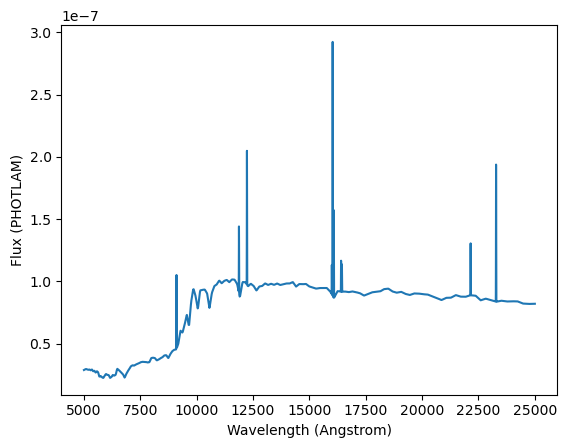

In [6]:
disk_flux.plot()

For the grism simulations we probably just need the wavelengths and associated fluxes, which can be accessed as follows

In [7]:
print(disk_flux.waveset)

[ 5000.          5020.02002002  5040.04004004 ... 24959.95995996
 24979.97997998 25000.        ] Angstrom


In [8]:
print(disk_flux(disk_flux.waveset))

[2.87159752e-08 2.89266690e-08 2.91356890e-08 ... 8.19834636e-08
 8.19793546e-08 8.19312873e-08] PHOTLAM


Note that these are both arrays of astropy quantities, so they can be expressed in other (suitable) units.

In [9]:
print(disk_flux.waveset.to(u.micron))

[0.5      0.502002 0.504004 ... 2.495996 2.497998 2.5     ] micron


And the flux can be expressed per unit wavelength or frequency, and can be used with astropy unit functionality.

In [10]:
print(disk_flux(disk_flux.waveset, flux_unit='FNU'))
print(disk_flux(disk_flux.waveset, flux_unit='FLAM'))
u.fnu = u.erg/u.s/u.cm**2/u.Hz # see e.g. https://synphot.readthedocs.io/en/stable/synphot/units.html
print(disk_flux(disk_flux.waveset, flux_unit='FNU').to_value(u.fnu))

[9.51370331e-31 9.62187930e-31 9.73005530e-31 ... 1.35589537e-29
 1.35691490e-29 1.35720614e-29] FNU
[1.14085460e-19 1.14464208e-19 1.14833351e-19 ... 6.52467840e-20
 6.51912249e-20 6.51008265e-20] FLAM
[9.51370331e-31 9.62187930e-31 9.73005530e-31 ... 1.35589537e-29
 1.35691490e-29 1.35720614e-29]


#### Wavelength arrays

The `synphot` `Spectrum1D` object that is returned has a non-uniform wavelength resolution. This is because we first generate a `SourceSpectrum` object for the continuum flux, and then add to it `SourceSpectrum` objects for each emission line. The wavelength-range and wavelength-resolution of each emission line spectrum is determined by `synphot` to properly cover and resolve the line. The result of adding these together is a spectrum on a non-uniform wavelength grid, with higher resolution around the emission lines. Maybe this is OK (or even desirable) in terms of putting this spectrum into `grizli`, but I thought I should point this out in case we want/need to ensure a uniform wavelength grid before passing this to `grizli`.

Text(0, 0.5, '$\\lambda \\, / \\, \\mathrm{micron}$')

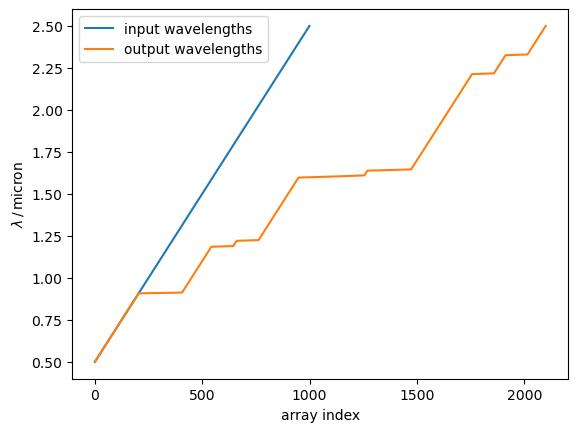

In [11]:
plt.plot(obs_wavelengths.to_value('micron'), label='input wavelengths')
plt.plot(disk_flux.waveset.to_value('micron'), label='output wavelengths')
plt.legend()
plt.xlabel('array index')
plt.ylabel(r'$\lambda \, / \, \mathrm{micron}$')

If we do want to use a uniform grid of wavelengths, this will need to be high enough resolution to properly resolve the emission lines. To see what happens if we don't do this, inspect the right panel of the figure below (which zooms in on the brightest emission line from the spectrum on the right). The flux in the emission lines is not conserved, because the lower-resolution spectrum is found with simple interpolation from the native resolution spectrum.

Text(0, 0.5, '$F_\\nu \\, / \\, \\mathrm{erg \\, s^{-1} \\, cm^{-2} \\, Hz^{-1}}$')

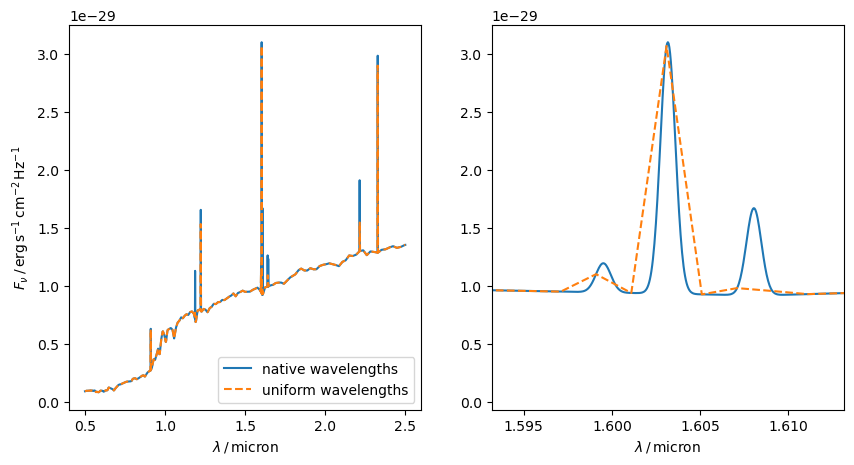

In [12]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
for ax in axs:
    ax.plot(disk_flux.waveset.to_value('micron'), disk_flux(disk_flux.waveset, flux_unit='FNU'), label='native wavelengths')
    ax.plot(obs_wavelengths.to_value('micron'), disk_flux(obs_wavelengths, flux_unit='FNU'), label='uniform wavelengths',ls='--')
    ax.set_xlabel(r'$\lambda \, / \, \mathrm{micron}$')
peak_wav = (disk_flux.waveset[disk_flux(disk_flux.waveset, flux_unit='FNU').argmax()]).to_value('micron')
axs[1].set_xlim(peak_wav-0.01, peak_wav+0.01)
axs[0].legend()
axs[0].set_ylabel('' + r'$F_\nu \, / \, \mathrm{erg \, s^{-1} \, cm^{-2} \, Hz^{-1}}$')

If instead we interpolate onto a high resolution uniform grid of wavelengths then all is well.

Text(0, 0.5, '$F_\\nu \\, / \\, \\mathrm{erg \\, s^{-1} \\, cm^{-2} \\, Hz^{-1}}$')

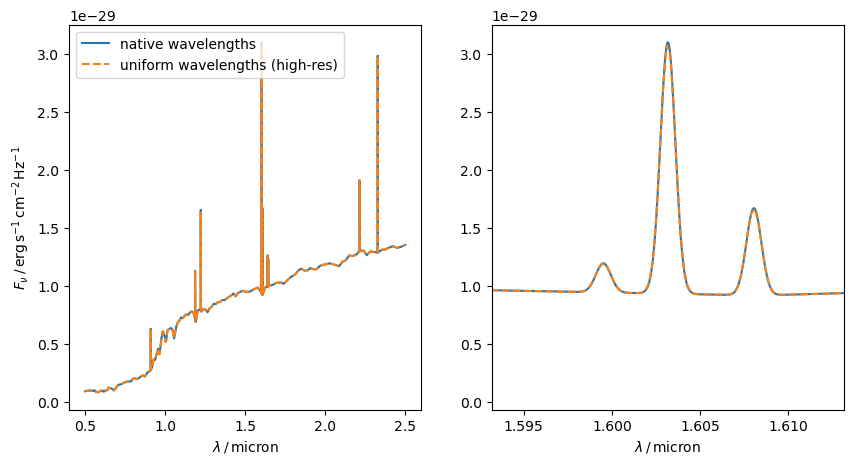

In [13]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
high_res_wavelengths = np.linspace(0.5, 2.5, 10000)*u.micron
for ax in axs:
    ax.plot(disk_flux.waveset.to_value('micron'), disk_flux(disk_flux.waveset, flux_unit='FNU'), label='native wavelengths')
    ax.plot(high_res_wavelengths.to_value('micron'), disk_flux(high_res_wavelengths, flux_unit='FNU'), label='uniform wavelengths (high-res)',ls='--')
    ax.set_xlabel(r'$\lambda \, / \, \mathrm{micron}$')
peak_wav = (disk_flux.waveset[disk_flux(disk_flux.waveset, flux_unit='FNU').argmax()]).to_value('micron')
axs[1].set_xlim(peak_wav-0.01, peak_wav+0.01)
axs[0].legend()
axs[0].set_ylabel('' + r'$F_\nu \, / \, \mathrm{erg \, s^{-1} \, cm^{-2} \, Hz^{-1}}$')

Depending on how we use the Galacticus galaxies in the grism simulations, we may want to get spectra for each component individually, or just for the galaxy as a whole. The example below plots the spectra for each galactic component (`disk`, `spheroid` and `AGN`) separately, as well as their combination.  

(0.0, 3.4321289027311693e-29)

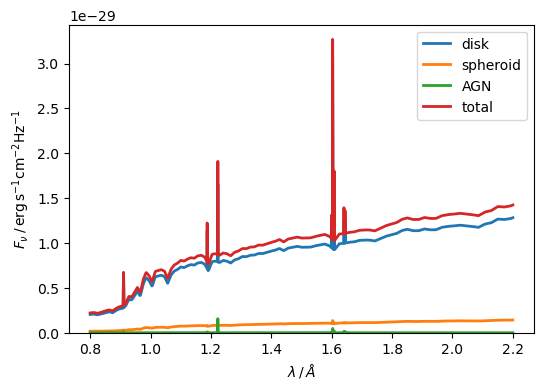

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

plotWavelengths = np.linspace(0.8,2.2,10000)*u.micron

spectra = []
for component in ['disk', 'spheroid', 'AGN']:
    component_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=obs_wavelengths)
    ax.plot(plotWavelengths, component_flux(plotWavelengths, flux_unit='FNU'), lw=2, label=component)
total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, obs_wavelengths=obs_wavelengths)
ax.plot(plotWavelengths, total_flux(plotWavelengths, flux_unit='FNU'), label='total', lw=2)
ax.set_xlabel(r'$\lambda \, / \, \AA$')
ax.legend()
ax.set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
ax.set_ylim(ymin=0)

#### Emission line widths
One thing I haven't thought much about is the width of the emission lines. Currently the `sedCalc.evaluate_component_spectrum` and `sedCalc.evaluate_total_spectrum` are set up to accept a `lineFWHM` which is the observed-frame FWHM of every emission line (as a wavelength). If we want something different (same $\Delta \lambda / \lambda$ for each line, or a different $\Delta \lambda$ for every line, etc.) then this would be easy enough to do.

As an example of changing the `lineFWHM`, below we make the lines broader.

(0.0, 1.4949699951156043e-29)

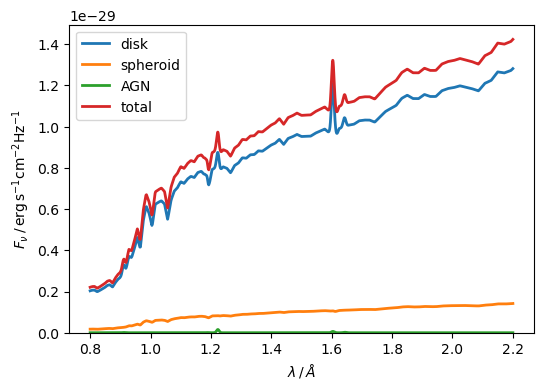

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))

plotWavelengths = np.linspace(0.8,2.2,10000)*u.micron
emissionLineWidth = 0.01*u.micron

spectra = []
for component in ['disk', 'spheroid', 'AGN']:
    component_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=obs_wavelengths, lineFWHM=emissionLineWidth)
    ax.plot(plotWavelengths, component_flux(plotWavelengths, flux_unit='FNU'), lw=2, label=component)
total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, obs_wavelengths=obs_wavelengths, lineFWHM=emissionLineWidth)
ax.plot(plotWavelengths, total_flux(plotWavelengths, flux_unit='FNU'), label='total', lw=2)
ax.set_xlabel(r'$\lambda \, / \, \AA$')
ax.legend()
ax.set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
ax.set_ylim(ymin=0)